<a href="https://colab.research.google.com/github/jeevaprakash-S/24ADI003_24BAD048/blob/main/EX06_SC5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, precision_recall_curve,
                            average_precision_score, f1_score,
                            recall_score, precision_score)
from imblearn.over_sampling import SMOTE

clr_normal = '#2A9D8F'
clr_fraud  = '#E76F51'
clr_models = ['#264653', '#2A9D8F', '#E9C46A']


In [2]:
df = pd.read_csv("fraud_smote.csv")


print(df.head())
print("\nMissing values:\n", df.isnull().sum())


    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0

Missing values:
 Amount      0
Time        0
Feature1    0
Feature2    0
Fraud       0
dtype: int64


In [3]:

class_counts = df['Fraud'].value_counts()
fraud_count  = class_counts.get(1, 0)
normal_count = class_counts.get(0, 0)
fraud_pct    = fraud_count / len(df) * 100

print(f"\n── Class Distribution (Full Dataset) ──")
print(f"  Normal (0) : {normal_count}")
print(f"  Fraud  (1) : {fraud_count}")
print(f"  Fraud %    : {fraud_pct:.2f}%")


── Class Distribution (Full Dataset) ──
  Normal (0) : 110
  Fraud  (1) : 10
  Fraud %    : 8.33%


### FEATURES & TARGET

In [4]:

feature_names = ['Amount', 'Time', 'Feature1', 'Feature2']
X = df[feature_names]
y = df['Fraud']


scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=7, stratify=y
)

print(f"\nTrain size : {len(X_train)}  |  Test size : {len(X_test)}")
print(f"Fraud in test set : {y_test.sum()} / {len(y_test)}")


Train size : 90  |  Test size : 30
Fraud in test set : 3 / 30


### MODEL A – NO BALANCING

In [5]:

print("\n" + "─" * 60)
print("MODEL A – Logistic Regression (No balancing)")
lr_plain = LogisticRegression(max_iter=1000, random_state=42)
lr_plain.fit(X_train, y_train)
y_pred_plain = lr_plain.predict(X_test)
y_prob_plain = lr_plain.predict_proba(X_test)[:, 1]

acc_plain = accuracy_score(y_test, y_pred_plain)
rec_plain = recall_score(y_test, y_pred_plain,  zero_division=0)
f1_plain  = f1_score(y_test, y_pred_plain,      zero_division=0)
ap_plain  = average_precision_score(y_test, y_prob_plain)

print(f"  Accuracy        : {acc_plain:.4f}")
print(f"  Recall  (Fraud) : {rec_plain:.4f}")
print(f"  F1      (Fraud) : {f1_plain:.4f}")
print(f"  Avg Precision   : {ap_plain:.4f}")
print(classification_report(y_test, y_pred_plain,
    target_names=["Normal", "Fraud"], zero_division=0))


────────────────────────────────────────────────────────────
MODEL A – Logistic Regression (No balancing)
  Accuracy        : 0.9000
  Recall  (Fraud) : 0.0000
  F1      (Fraud) : 0.0000
  Avg Precision   : 0.1322
              precision    recall  f1-score   support

      Normal       0.90      1.00      0.95        27
       Fraud       0.00      0.00      0.00         3

    accuracy                           0.90        30
   macro avg       0.45      0.50      0.47        30
weighted avg       0.81      0.90      0.85        30



### APPLY SMOTE

In [6]:
fraud_train_count = int(y_train.sum())
k = max(1, min(fraud_train_count - 1, 5))
print(f"\nSMOTE k_neighbors = {k}  (fraud samples in train = {fraud_train_count})")

smote = SMOTE(k_neighbors=k, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

sm_counts = pd.Series(y_train_sm).value_counts()
print(f"\n── After SMOTE (train set) ──")
print(f"  Normal (0) : {sm_counts.get(0, 0)}")
print(f"  Fraud  (1) : {sm_counts.get(1, 0)}")


SMOTE k_neighbors = 5  (fraud samples in train = 7)

── After SMOTE (train set) ──
  Normal (0) : 83
  Fraud  (1) : 83


### MODEL B – AFTER SMOTE

In [7]:

print("\n" + "─" * 60)
print("MODEL B – Logistic Regression (After SMOTE)")
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote,  zero_division=0)
f1_smote  = f1_score(y_test, y_pred_smote,      zero_division=0)
ap_smote  = average_precision_score(y_test, y_prob_smote)

print(f"  Accuracy        : {acc_smote:.4f}")
print(f"  Recall  (Fraud) : {rec_smote:.4f}")
print(f"  F1      (Fraud) : {f1_smote:.4f}")
print(f"  Avg Precision   : {ap_smote:.4f}")
print(classification_report(y_test, y_pred_smote,
    target_names=["Normal", "Fraud"], zero_division=0))


────────────────────────────────────────────────────────────
MODEL B – Logistic Regression (After SMOTE)
  Accuracy        : 0.7000
  Recall  (Fraud) : 0.6667
  F1      (Fraud) : 0.3077
  Avg Precision   : 0.2000
              precision    recall  f1-score   support

      Normal       0.95      0.70      0.81        27
       Fraud       0.20      0.67      0.31         3

    accuracy                           0.70        30
   macro avg       0.57      0.69      0.56        30
weighted avg       0.88      0.70      0.76        30



### MODEL C – SMOTE + THRESHOLD TUNING

In [8]:

print("\n" + "─" * 60)
print("MODEL C – SMOTE + Best Threshold (maximises F1 for Fraud)")

best_thresh = 0.5
best_f1_val = 0.0

for thresh in np.arange(0.05, 0.95, 0.01):
    y_pred_t = (y_prob_smote >= thresh).astype(int)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    if f > best_f1_val:
        best_f1_val = f
        best_thresh = thresh

y_pred_tuned = (y_prob_smote >= best_thresh).astype(int)
acc_tuned    = accuracy_score(y_test, y_pred_tuned)
rec_tuned    = recall_score(y_test,   y_pred_tuned, zero_division=0)
f1_tuned     = f1_score(y_test,       y_pred_tuned, zero_division=0)
prec_tuned   = precision_score(y_test, y_pred_tuned, zero_division=0)

print(f"  Best threshold  : {best_thresh:.2f}")
print(f"  Accuracy        : {acc_tuned:.4f}")
print(f"  Precision(Fraud): {prec_tuned:.4f}")
print(f"  Recall  (Fraud) : {rec_tuned:.4f}")
print(f"  F1      (Fraud) : {f1_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned,
    target_names=["Normal", "Fraud"], zero_division=0))


────────────────────────────────────────────────────────────
MODEL C – SMOTE + Best Threshold (maximises F1 for Fraud)
  Best threshold  : 0.51
  Accuracy        : 0.7333
  Precision(Fraud): 0.2222
  Recall  (Fraud) : 0.6667
  F1      (Fraud) : 0.3333
              precision    recall  f1-score   support

      Normal       0.95      0.74      0.83        27
       Fraud       0.22      0.67      0.33         3

    accuracy                           0.73        30
   macro avg       0.59      0.70      0.58        30
weighted avg       0.88      0.73      0.78        30



### SUMMARY TABLE

In [9]:

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Metric':<22}  {'No Balancing':>13}  {'SMOTE':>8}  {'SMOTE+Thresh':>13}")
print("-" * 62)
print(f"{'Accuracy':<22}  {acc_plain:>13.4f}  {acc_smote:>8.4f}  {acc_tuned:>13.4f}")
print(f"{'Recall (Fraud)':<22}  {rec_plain:>13.4f}  {rec_smote:>8.4f}  {rec_tuned:>13.4f}")
print(f"{'F1-Score (Fraud)':<22}  {f1_plain:>13.4f}  {f1_smote:>8.4f}  {f1_tuned:>13.4f}")
print(f"{'Avg Precision':<22}  {ap_plain:>13.4f}  {ap_smote:>8.4f}  {ap_smote:>13.4f}")



PERFORMANCE COMPARISON SUMMARY
Metric                   No Balancing     SMOTE   SMOTE+Thresh
--------------------------------------------------------------
Accuracy                       0.9000    0.7000         0.7333
Recall (Fraud)                 0.0000    0.6667         0.6667
F1-Score (Fraud)               0.0000    0.3077         0.3333
Avg Precision                  0.1322    0.2000         0.2000


## VISULAIZATION

### SMOTE VS BEFORE SMOTE

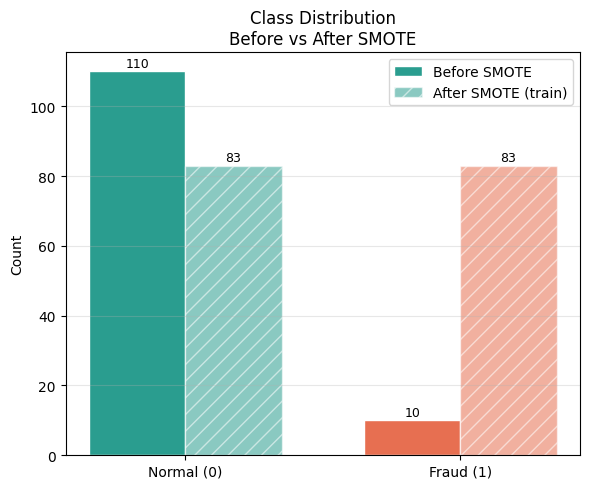

In [10]:
plt.figure(figsize=(6, 5))

categories  = ['Normal (0)', 'Fraud (1)']
before_vals = [normal_count, fraud_count]
after_vals  = [sm_counts.get(0, 0), sm_counts.get(1, 0)]

x = np.arange(2)
width = 0.35

b1 = plt.bar(x - width/2, before_vals, width,
             label='Before SMOTE',
             color=[clr_normal, clr_fraud], edgecolor='white')

b2 = plt.bar(x + width/2, after_vals, width,
             label='After SMOTE (train)',
             color=[clr_normal, clr_fraud],
             edgecolor='white', alpha=0.55, hatch='//')

for bar, val in zip(list(b1) + list(b2), before_vals + after_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4, str(val),
             ha='center', va='bottom', fontsize=9)

plt.xticks(x, categories)
plt.title("Class Distribution\nBefore vs After SMOTE")
plt.ylabel("Count")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### PRECISION RECALL CRUVE

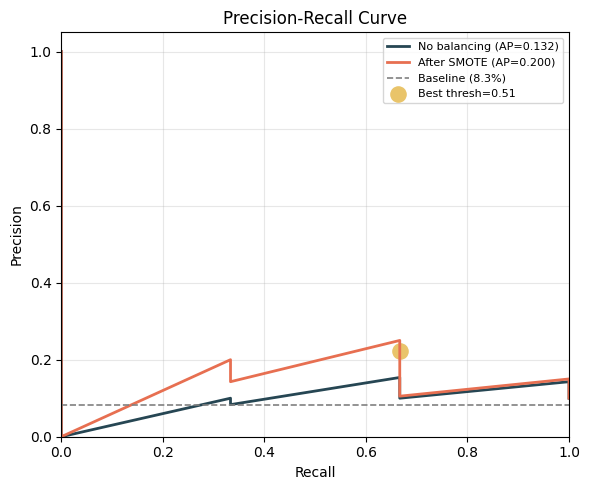

In [11]:
plt.figure(figsize=(6, 5))

prec_p, rec_p, _ = precision_recall_curve(y_test, y_prob_plain)
prec_s, rec_s, _ = precision_recall_curve(y_test, y_prob_smote)

plt.plot(rec_p, prec_p, color='#264653', lw=2,
        label=f'No balancing (AP={ap_plain:.3f})')

plt.plot(rec_s, prec_s, color='#E76F51', lw=2,
        label=f'After SMOTE (AP={ap_smote:.3f})')

plt.axhline(y=fraud_pct/100, color='grey',
            linestyle='--', lw=1.2,
            label=f'Baseline ({fraud_pct:.1f}%)')

plt.scatter(rec_tuned, prec_tuned,
            color='#E9C46A', s=120,
            label=f'Best thresh={best_thresh:.2f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(fontsize=8)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

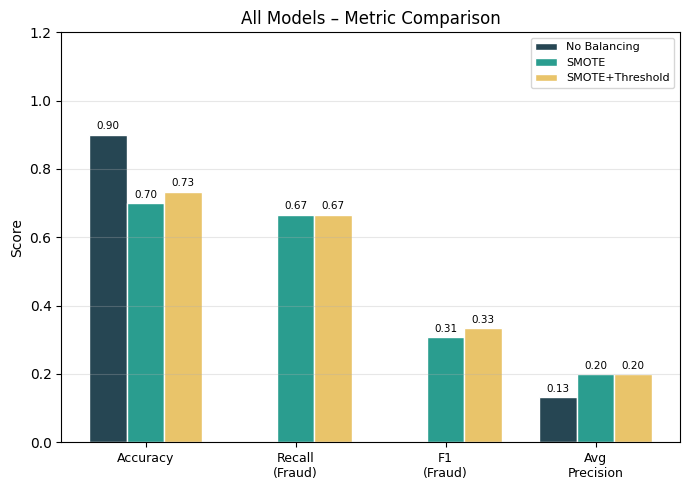

In [12]:
plt.figure(figsize=(7, 5))

metrics      = ['Accuracy', 'Recall\n(Fraud)', 'F1\n(Fraud)', 'Avg\nPrecision']
scores_plain = [acc_plain, rec_plain, f1_plain, ap_plain]
scores_smote = [acc_smote, rec_smote, f1_smote, ap_smote]
scores_tuned = [acc_tuned, rec_tuned, f1_tuned, ap_smote]

x = np.arange(len(metrics))
width = 0.25

b1 = plt.bar(x - width, scores_plain, width,
            label='No Balancing', color=clr_models[0], edgecolor='white')

b2 = plt.bar(x, scores_smote, width,
            label='SMOTE', color=clr_models[1], edgecolor='white')

b3 = plt.bar(x + width, scores_tuned, width,
            label='SMOTE+Threshold', color=clr_models[2], edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            plt.text(bar.get_x() + bar.get_width()/2,
                    h + 0.01, f"{h:.2f}",
                    ha='center', va='bottom', fontsize=7.5)

plt.xticks(x, metrics, fontsize=9)
plt.ylim(0, 1.2)
plt.ylabel("Score")
plt.title("All Models – Metric Comparison")
plt.legend(fontsize=8)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()